# Respiratory Disease Prediction - Data Profiling
## Directory Structure

```
project/
    data/
        raw/
            pm25/         daily_88101_YYYY.csv
            no2/          daily_42602_YYYY.csv
            ozone/        daily_44201_YYYY.csv
            temperature/  daily_TEMP_YYYY.csv
            humidity/     daily_RH_DP_YYYY.csv
            respiratory/  nssp_respiratory.csv
```

## Setup

In [1]:
import pathlib
if pathlib.Path.cwd().name == "notebooks":
    import os; os.chdir(pathlib.Path.cwd().parent)

import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_rows', 20)

for d in ['data/processed', 'outputs/figures']:
    os.makedirs(d, exist_ok=True)

# Reference only - profiling examines full raw data without date filtering.
# The cleaning notebook applies the actual study window: 2022-09-25 to 2025-10-31.
STUDY_START = '2022-09-25'
STUDY_END   = '2025-10-31'

print('Setup complete.')
print(f'Study period (reference): {STUDY_START} to {STUDY_END}')

Setup complete.
Study period (reference): 2022-09-25 to 2025-10-31


For each dataset we answer:
1. What does the raw structure look like?
2. What are the date ranges and granularity?
3. Are there missing values, and where?
4. Are there duplicates?
5. What do the value distributions look like?
6. Are there outliers that could be sensor errors vs real events?


In [2]:
def profile_dataset(df, name, date_col, value_cols):
    """
    Prints a structured profile report for a dataframe.
    Records shape, dtypes, missing values, duplicates,
    date coverage, and value distributions.
    """

    print(f'PROFILE: {name}')


    # Basic shape
    print(f'\n[1] Shape: {df.shape[0]} rows x {df.shape[1]} columns')
    print(f'    Columns: {list(df.columns)}')

    # Dtypes
    print(f'\n[2] Data types:')
    for col, dtype in df.dtypes.items():
        print(f'    {col:<35} {dtype}')

    # Date coverage
    if date_col in df.columns:
        dates = pd.to_datetime(df[date_col], format='mixed', errors='coerce')
        print(f'\n[3] Date range: {dates.min()} to {dates.max()}')
        print(f'    Unique dates: {dates.nunique()}')
        print(f'    Unparseable dates: {dates.isna().sum()}')

        # Check for gaps in the date sequence
        sorted_dates = dates.dropna().sort_values().unique()
        if len(sorted_dates) > 1:
            full_range = pd.date_range(sorted_dates[0], sorted_dates[-1], freq='D')
            missing_dates = full_range.difference(sorted_dates)
            print(f'    Expected days in range: {len(full_range)}')
            print(f'    Missing days in sequence: {len(missing_dates)}')
            if len(missing_dates) > 0 and len(missing_dates) <= 20:
                print(f'    Missing dates: {list(missing_dates.strftime("%Y-%m-%d"))}')
            elif len(missing_dates) > 20:
                print(f'    First 10 missing: {list(missing_dates[:10].strftime("%Y-%m-%d"))}')

    # Missing values
    print(f'\n[4] Missing values per column:')
    null_counts = df.isnull().sum()
    null_pct = (null_counts / len(df) * 100).round(2)
    for col in df.columns:
        if null_counts[col] > 0:
            print(f'    {col:<35} {null_counts[col]} ({null_pct[col]}%)')
    if null_counts.sum() == 0:
        print('    None.')

    # Duplicates
    dup_count = df.duplicated().sum()
    print(f'\n[5] Duplicate rows: {dup_count}')
    if date_col in df.columns:
        unique_dates = df[date_col].nunique()
        total_rows   = len(df)
        print(f'    Unique date values: {unique_dates} across {total_rows:,} rows '
              f'(ratio {total_rows / unique_dates:.1f} rows/date - '
              f'{"expected: multiple stations per day" if total_rows / unique_dates > 1.5 else "one row per date"})')

    # Value distributions
    print(f'\n[6] Value distributions (numeric columns):')
    num_cols = [c for c in value_cols if c in df.columns]
    if num_cols:
        desc = df[num_cols].describe().T
        print(desc.to_string())

    # Outlier check using IQR
    print(f'\n[7] Outlier check (values beyond 3 x IQR from median):')
    for col in num_cols:
        series = pd.to_numeric(df[col], errors='coerce').dropna()
        q1, q3 = series.quantile(0.25), series.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 3 * iqr
        upper = q3 + 3 * iqr
        outliers = series[(series < lower) | (series > upper)]
        print(f'    {col:<35} {len(outliers)} outliers | range [{lower:.3f}, {upper:.3f}] | '
              f'actual [{series.min():.3f}, {series.max():.3f}]')

    print(f'\n[8] First 3 rows:')
    print(df.head(3).to_string())
    print()

---
## Profile 1 - PM2.5

Source: EPA AQS `daily_88101_YYYY.csv`  
Expected: One row per monitoring station per day, `Date Local` and `Arithmetic Mean` (µg/m³)

In [3]:
folder = 'data/raw/pm25'
files  = sorted([os.path.join(folder, f) for f in os.listdir(folder)
                 if f.startswith('daily_88101') and f.endswith('.csv')])
print(f'Files found: {[os.path.basename(f) for f in files]}')

pm25_raw = pd.concat([pd.read_csv(f, low_memory=False) for f in files], ignore_index=True)
pm25_raw.columns = [c.strip() for c in pm25_raw.columns]

# Profiling the raw multi-station data 
profile_dataset(
    pm25_raw,
    name       = 'PM2.5 (raw, all stations)',
    date_col   = 'Date Local',
    value_cols = ['Arithmetic Mean', 'AQI']
)

Files found: ['daily_88101_2022.csv', 'daily_88101_2023.csv', 'daily_88101_2024.csv', 'daily_88101_2025.csv']


PROFILE: PM2.5 (raw, all stations)

[1] Shape: 2915841 rows x 29 columns
    Columns: ['State Code', 'County Code', 'Site Num', 'Parameter Code', 'POC', 'Latitude', 'Longitude', 'Datum', 'Parameter Name', 'Sample Duration', 'Pollutant Standard', 'Date Local', 'Units of Measure', 'Event Type', 'Observation Count', 'Observation Percent', 'Arithmetic Mean', '1st Max Value', '1st Max Hour', 'AQI', 'Method Code', 'Method Name', 'Local Site Name', 'Address', 'State Name', 'County Name', 'City Name', 'CBSA Name', 'Date of Last Change']

[2] Data types:
    State Code                          int64
    County Code                         int64
    Site Num                            int64
    Parameter Code                      int64
    POC                                 int64
    Latitude                            float64
    Longitude                           float64
    Datum                               str
    Parameter Name                      str
    Sample Duration               

    Expected days in range: 1412
    Missing days in sequence: 0

[4] Missing values per column:


    Pollutant Standard                  1353266 (46.41%)
    Event Type                          2391657 (82.02%)
    AQI                                 1353266 (46.41%)
    Local Site Name                     77246 (2.65%)
    Address                             1431 (0.05%)
    CBSA Name                           226097 (7.75%)



[5] Duplicate rows: 0
    Unique date values: 1412 across 2,915,841 rows (ratio 2065.0 rows/date - expected: multiple stations per day)

[6] Value distributions (numeric columns):
                       count    mean     std     min     25%     50%     75%       max
Arithmetic Mean 2915841.0000  7.7220  6.6233 -7.7750  4.3000  6.4083  9.5000  833.8429
AQI             1562575.0000 37.6592 19.0215  0.0000 24.0000 36.0000 52.0000 1513.0000

[7] Outlier check (values beyond 3 x IQR from median):
    Arithmetic Mean                     43124 outliers | range [-11.300, 25.100] | actual [-7.775, 833.843]
    AQI                                 3502 outliers | range [-60.000, 136.000] | actual [0.000, 1513.000]

[8] First 3 rows:
   State Code  County Code  Site Num  Parameter Code  POC  Latitude  Longitude  Datum            Parameter Name Sample Duration Pollutant Standard Date Local             Units of Measure Event Type  Observation Count  Observation Percent  Arithmetic Mean  1st Max Val

In [4]:
# Unique Monitoring Stations
print(f"Unique states:    {pm25_raw['State Name'].nunique()}")
print(f"Unique counties:  {pm25_raw['County Name'].nunique() if 'County Name' in pm25_raw.columns else 'N/A'}")
print(f"Unique sites:     {pm25_raw['Site Num'].nunique() if 'Site Num' in pm25_raw.columns else 'N/A'}")

# How many stations report per day on average?
daily_station_counts = pm25_raw.groupby('Date Local').size()
print(f"\nStations reporting per day:")
print(f"  Mean:   {daily_station_counts.mean():.0f}")
print(f"  Min:    {daily_station_counts.min()}")
print(f"  Max:    {daily_station_counts.max()}")
print(f"\nDays with fewer than 100 stations reporting:")
sparse_days = daily_station_counts[daily_station_counts < 100]
print(f"  Count: {len(sparse_days)}")
if len(sparse_days) > 0:
    print(f"  Dates: {list(sparse_days.head(10).index)}")

Unique states:    54
Unique counties:  548
Unique sites:     293

Stations reporting per day:
  Mean:   2065
  Min:    6
  Max:    2875

Days with fewer than 100 stations reporting:
  Count: 12
  Dates: ['2025-11-01', '2025-11-02', '2025-11-03', '2025-11-04', '2025-11-05', '2025-11-06', '2025-11-07', '2025-11-08', '2025-11-09', '2025-11-10']


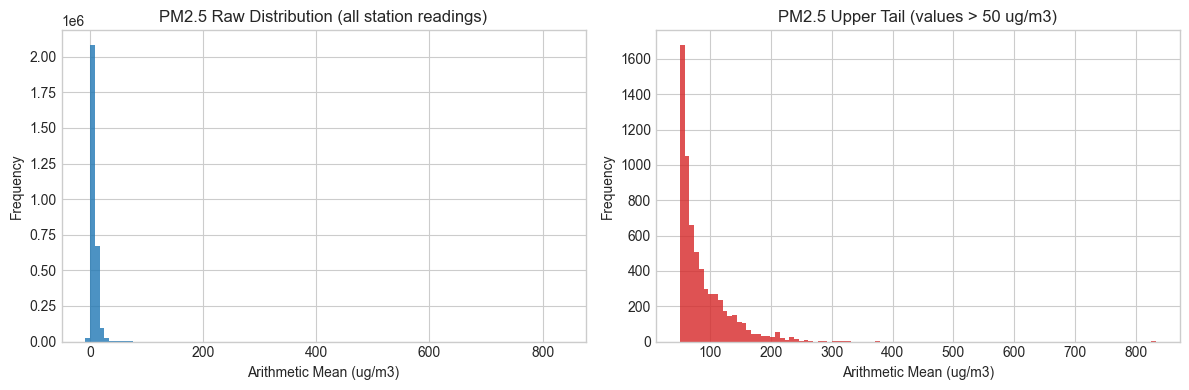

Values above 200 ug/m3 (WHO extreme threshold): 192
Values above 500 ug/m3 (likely sensor error):   2
Negative values (impossible):                   10148


In [5]:
# Visualizing the Arithmetic Mean distribution to identify outlier ranges
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pm25_vals = pd.to_numeric(pm25_raw['Arithmetic Mean'], errors='coerce').dropna()

axes[0].hist(pm25_vals, bins=100, color='#1f77b4', edgecolor='none', alpha=0.8)
axes[0].set_title('PM2.5 Raw Distribution (all station readings)')
axes[0].set_xlabel('Arithmetic Mean (ug/m3)')
axes[0].set_ylabel('Frequency')

# Zoom into the upper tail to see extreme values
axes[1].hist(pm25_vals[pm25_vals > 50], bins=100, color='#d62728', edgecolor='none', alpha=0.8)
axes[1].set_title('PM2.5 Upper Tail (values > 50 ug/m3)')
axes[1].set_xlabel('Arithmetic Mean (ug/m3)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('outputs/figures/profile_pm25_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Values above 200 ug/m3 (WHO extreme threshold): {(pm25_vals > 200).sum()}')
print(f'Values above 500 ug/m3 (likely sensor error):   {(pm25_vals > 500).sum()}')
print(f'Negative values (impossible):                   {(pm25_vals < 0).sum()}')

---
## Profile 2 - NO2

Source: EPA AQS `daily_42602_YYYY.csv`  
Expected: One row per monitoring station per day, `Arithmetic Mean` in ppb

In [6]:
folder = 'data/raw/no2'
files  = sorted([os.path.join(folder, f) for f in os.listdir(folder)
                 if f.startswith('daily_42602') and f.endswith('.csv')])
print(f'Files found: {[os.path.basename(f) for f in files]}')

no2_raw = pd.concat([pd.read_csv(f, low_memory=False) for f in files], ignore_index=True)
no2_raw.columns = [c.strip() for c in no2_raw.columns]

profile_dataset(
    no2_raw,
    name       = 'NO2 (raw, all stations)',
    date_col   = 'Date Local',
    value_cols = ['Arithmetic Mean', 'AQI']
)

no2_vals = pd.to_numeric(no2_raw['Arithmetic Mean'], errors='coerce').dropna()
print(f'Negative values (impossible for NO2):          {(no2_vals < 0).sum()}')
print(f'Values above 200 ppb (extreme):                {(no2_vals > 200).sum()}')

Files found: ['daily_42602_2022.csv', 'daily_42602_2023.csv', 'daily_42602_2024.csv', 'daily_42602_2025.csv']


PROFILE: NO2 (raw, all stations)

[1] Shape: 562605 rows x 29 columns
    Columns: ['State Code', 'County Code', 'Site Num', 'Parameter Code', 'POC', 'Latitude', 'Longitude', 'Datum', 'Parameter Name', 'Sample Duration', 'Pollutant Standard', 'Date Local', 'Units of Measure', 'Event Type', 'Observation Count', 'Observation Percent', 'Arithmetic Mean', '1st Max Value', '1st Max Hour', 'AQI', 'Method Code', 'Method Name', 'Local Site Name', 'Address', 'State Name', 'County Name', 'City Name', 'CBSA Name', 'Date of Last Change']

[2] Data types:
    State Code                          int64
    County Code                         int64
    Site Num                            int64
    Parameter Code                      int64
    POC                                 int64
    Latitude                            float64
    Longitude                           float64
    Datum                               str
    Parameter Name                      str
    Sample Duration                  


[5] Duplicate rows: 0
    Unique date values: 1401 across 562,605 rows (ratio 401.6 rows/date - expected: multiple stations per day)

[6] Value distributions (numeric columns):
                      count    mean     std     min    25%     50%     75%      max
Arithmetic Mean 562605.0000  7.5820  6.6525 -4.5786 2.6913  5.5833 10.6190  64.0583
AQI             562605.0000 14.9243 11.2335  0.0000 6.0000 12.0000 22.0000 108.0000

[7] Outlier check (values beyond 3 x IQR from median):
    Arithmetic Mean                     2135 outliers | range [-21.092, 34.402] | actual [-4.579, 64.058]
    AQI                                 112 outliers | range [-42.000, 70.000] | actual [0.000, 108.000]

[8] First 3 rows:
   State Code  County Code  Site Num  Parameter Code  POC  Latitude  Longitude  Datum          Parameter Name Sample Duration Pollutant Standard  Date Local   Units of Measure Event Type  Observation Count  Observation Percent  Arithmetic Mean  1st Max Value  1st Max Hour  AQI  Metho

In [7]:
no2_vals = pd.to_numeric(no2_raw['Arithmetic Mean'], errors='coerce').dropna()
print(f"Date range: {no2_raw['Date Local'].min()} to {no2_raw['Date Local'].max()}")
print(f"Value range: {no2_vals.min():.3f} to {no2_vals.max():.3f}")
print(f"Mean: {no2_vals.mean():.3f} | Std: {no2_vals.std():.3f}")
print(f"Unique dates: {no2_raw['Date Local'].nunique()}")
print(f"\nSample Duration breakdown:")
print(no2_raw['Sample Duration'].value_counts().to_string())

Date range: 2022-01-01 to 2025-11-01
Value range: -4.579 to 64.058
Mean: 7.582 | Std: 6.653
Unique dates: 1401

Sample Duration breakdown:
Sample Duration
1 HOUR    562605


---
## Profile 3 - Ozone

Source: EPA AQS `daily_44201_YYYY.csv`  
Expected: `Arithmetic Mean` in ppm. Typical range 0.01 to 0.10 ppm. Above 0.15 is extreme.

In [8]:
folder = 'data/raw/ozone'
files  = sorted([os.path.join(folder, f) for f in os.listdir(folder)
                 if f.startswith('daily_44201') and f.endswith('.csv')])
print(f'Files found: {[os.path.basename(f) for f in files]}')

ozone_raw = pd.concat([pd.read_csv(f, low_memory=False) for f in files], ignore_index=True)
ozone_raw.columns = [c.strip() for c in ozone_raw.columns]

profile_dataset(
    ozone_raw,
    name       = 'Ozone (raw, all stations)',
    date_col   = 'Date Local',
    value_cols = ['Arithmetic Mean', 'AQI']
)

ozone_vals = pd.to_numeric(ozone_raw['Arithmetic Mean'], errors='coerce').dropna()
print(f'Negative values (impossible):                  {(ozone_vals < 0).sum()}')
print(f'Values above 0.2 ppm (extreme, likely error):  {(ozone_vals > 0.2).sum()}')

Files found: ['daily_44201_2022.csv', 'daily_44201_2023.csv', 'daily_44201_2024.csv', 'daily_44201_2025.csv']


PROFILE: Ozone (raw, all stations)

[1] Shape: 1412282 rows x 29 columns
    Columns: ['State Code', 'County Code', 'Site Num', 'Parameter Code', 'POC', 'Latitude', 'Longitude', 'Datum', 'Parameter Name', 'Sample Duration', 'Pollutant Standard', 'Date Local', 'Units of Measure', 'Event Type', 'Observation Count', 'Observation Percent', 'Arithmetic Mean', '1st Max Value', '1st Max Hour', 'AQI', 'Method Code', 'Method Name', 'Local Site Name', 'Address', 'State Name', 'County Name', 'City Name', 'CBSA Name', 'Date of Last Change']

[2] Data types:
    State Code                          int64
    County Code                         int64
    Site Num                            int64
    Parameter Code                      int64
    POC                                 int64
    Latitude                            float64
    Longitude                           float64
    Datum                               str
    Parameter Name                      str
    Sample Duration               

    Event Type                          1373791 (97.27%)
    AQI                                 2 (0.0%)
    Method Code                         11 (0.0%)
    Local Site Name                     30353 (2.15%)
    Address                             730 (0.05%)
    CBSA Name                           148789 (10.54%)



[5] Duplicate rows: 0
    Unique date values: 1401 across 1,412,282 rows (ratio 1008.1 rows/date - expected: multiple stations per day)

[6] Value distributions (numeric columns):
                       count    mean     std     min     25%     50%     75%      max
Arithmetic Mean 1412282.0000  0.0334  0.0108 -0.0020  0.0259  0.0334  0.0407   0.1359
AQI             1412280.0000 41.1582 17.0444  0.0000 31.0000 39.0000 46.0000 291.0000

[7] Outlier check (values beyond 3 x IQR from median):
    Arithmetic Mean                     68 outliers | range [-0.019, 0.085] | actual [-0.002, 0.136]
    AQI                                 30641 outliers | range [-14.000, 91.000] | actual [0.000, 291.000]

[8] First 3 rows:
   State Code  County Code  Site Num  Parameter Code  POC  Latitude  Longitude  Datum Parameter Name          Sample Duration Pollutant Standard  Date Local   Units of Measure Event Type  Observation Count  Observation Percent  Arithmetic Mean  1st Max Value  1st Max Hour     A

---
## Profile 4 - Temperature

Source: EPA AQS `daily_TEMP_YYYY.csv`  
Expected: `Arithmetic Mean` in degrees. Check whether it is Fahrenheit or Celsius - this varies by station and year in EPA data.

In [9]:
folder = 'data/raw/temperature'
files  = sorted([os.path.join(folder, f) for f in os.listdir(folder)
                 if f.startswith('daily_TEMP') and f.endswith('.csv')])
print(f'Files found: {[os.path.basename(f) for f in files]}')

temp_raw = pd.concat([pd.read_csv(f, low_memory=False) for f in files], ignore_index=True)
temp_raw.columns = [c.strip() for c in temp_raw.columns]

profile_dataset(
    temp_raw,
    name       = 'Temperature (raw, all stations)',
    date_col   = 'Date Local',
    value_cols = ['Arithmetic Mean']
)

if 'Units of Measure' in temp_raw.columns:
    print('\nUnits of Measure found in data:')
    print(temp_raw['Units of Measure'].value_counts().to_string())

temp_vals = pd.to_numeric(temp_raw['Arithmetic Mean'], errors='coerce').dropna()
print(f'\nTemperature value range: {temp_vals.min():.1f} to {temp_vals.max():.1f}')
print('Note: if range is roughly -30 to 45, likely Celsius')
print('      if range is roughly -20 to 115, likely Fahrenheit')

Files found: ['daily_TEMP_2022.csv', 'daily_TEMP_2023.csv', 'daily_TEMP_2024.csv', 'daily_TEMP_2025.csv']


PROFILE: Temperature (raw, all stations)

[1] Shape: 1184025 rows x 29 columns
    Columns: ['State Code', 'County Code', 'Site Num', 'Parameter Code', 'POC', 'Latitude', 'Longitude', 'Datum', 'Parameter Name', 'Sample Duration', 'Pollutant Standard', 'Date Local', 'Units of Measure', 'Event Type', 'Observation Count', 'Observation Percent', 'Arithmetic Mean', '1st Max Value', '1st Max Hour', 'AQI', 'Method Code', 'Method Name', 'Local Site Name', 'Address', 'State Name', 'County Name', 'City Name', 'CBSA Name', 'Date of Last Change']

[2] Data types:
    State Code                          int64
    County Code                         int64
    Site Num                            int64
    Parameter Code                      int64
    POC                                 int64
    Latitude                            float64
    Longitude                           float64
    Datum                               str
    Parameter Name                      str
    Sample Duration         

    Pollutant Standard                  1184025 (100.0%)
    Event Type                          1184025 (100.0%)
    AQI                                 1184025 (100.0%)
    Local Site Name                     36428 (3.08%)
    Address                             730 (0.06%)
    CBSA Name                           129632 (10.95%)



[5] Duplicate rows: 0
    Unique date values: 1400 across 1,184,025 rows (ratio 845.7 rows/date - expected: multiple stations per day)

[6] Value distributions (numeric columns):
                       count    mean     std        min     25%     50%     75%      max
Arithmetic Mean 1184025.0000 57.7902 19.2935 -1177.6708 44.6667 59.8333 72.7917 179.5958

[7] Outlier check (values beyond 3 x IQR from median):
    Arithmetic Mean                     46 outliers | range [-39.708, 157.167] | actual [-1177.671, 179.596]

[8] First 3 rows:
   State Code  County Code  Site Num  Parameter Code  POC  Latitude  Longitude  Datum       Parameter Name Sample Duration  Pollutant Standard  Date Local    Units of Measure  Event Type  Observation Count  Observation Percent  Arithmetic Mean  1st Max Value  1st Max Hour  AQI  Method Code                               Method Name Local Site Name          Address State Name County Name      City Name CBSA Name Date of Last Change
0           1           

In [10]:
temp_vals = pd.to_numeric(temp_raw['Arithmetic Mean'], errors='coerce')
print(temp_vals[temp_vals < -100].value_counts().head(20))
print(f'\nRows below -100F: {(temp_vals < -100).sum()}')
print(f'Rows below -459F (below absolute zero): {(temp_vals < -459.67).sum()}')

Arithmetic Mean
-1177.6708    1
Name: count, dtype: int64

Rows below -100F: 1
Rows below -459F (below absolute zero): 1


In [11]:
print(temp_vals[temp_vals > 140].value_counts().head(20))
print(f'Rows above 140F: {(temp_vals > 140).sum()}')

Arithmetic Mean
141.2333    2
152.9250    1
155.8958    1
154.0500    1
145.8792    1
150.3708    1
153.0375    1
155.6042    1
157.0500    1
159.0458    1
159.6958    1
158.3208    1
156.8000    1
154.3375    1
150.7500    1
146.7750    1
148.4000    1
143.1292    1
144.9708    1
148.2667    1
Name: count, dtype: int64
Rows above 140F: 79


---
## Profile 5 - Humidity

Source: EPA AQS `daily_RH_DP_YYYY.csv`  
Expected: Contains both Relative Humidity (%) and Dew Point. We only need RH. Check the `Parameter Name` column to confirm which rows are which.

In [12]:
folder = 'data/raw/humidity'
files  = sorted([os.path.join(folder, f) for f in os.listdir(folder)
                 if f.startswith('daily_RH_DP') and f.endswith('.csv')])
print(f'Files found: {[os.path.basename(f) for f in files]}')

humidity_raw = pd.concat([pd.read_csv(f, low_memory=False) for f in files], ignore_index=True)
humidity_raw.columns = [c.strip() for c in humidity_raw.columns]

if 'Parameter Name' in humidity_raw.columns:
    print('Parameter types in this file:')
    print(humidity_raw['Parameter Name'].value_counts().to_string())
    print()

profile_dataset(
    humidity_raw,
    name       = 'Humidity/Dew Point (raw, all stations)',
    date_col   = 'Date Local',
    value_cols = ['Arithmetic Mean']
)

# Check RH-only distribution
if 'Parameter Name' in humidity_raw.columns:
    rh_only = humidity_raw[humidity_raw['Parameter Name'].str.contains('Relative Humidity', case=False, na=False)]
    rh_vals = pd.to_numeric(rh_only['Arithmetic Mean'], errors='coerce').dropna()
    print(f'\nRelative Humidity only rows: {len(rh_only)}')
    print(f'RH range: {rh_vals.min():.1f}% to {rh_vals.max():.1f}%')
    print(f'Values above 100% (impossible): {(rh_vals > 100).sum()}')
    print(f'Values below 0% (impossible):   {(rh_vals < 0).sum()}')

Files found: ['daily_RH_DP_2022.csv', 'daily_RH_DP_2023.csv', 'daily_RH_DP_2024.csv', 'daily_RH_DP_2025.csv']


Parameter types in this file:
Parameter Name
Relative Humidity     535740
Dew Point              43518

PROFILE: Humidity/Dew Point (raw, all stations)

[1] Shape: 579258 rows x 29 columns
    Columns: ['State Code', 'County Code', 'Site Num', 'Parameter Code', 'POC', 'Latitude', 'Longitude', 'Datum', 'Parameter Name', 'Sample Duration', 'Pollutant Standard', 'Date Local', 'Units of Measure', 'Event Type', 'Observation Count', 'Observation Percent', 'Arithmetic Mean', '1st Max Value', '1st Max Hour', 'AQI', 'Method Code', 'Method Name', 'Local Site Name', 'Address', 'State Name', 'County Name', 'City Name', 'CBSA Name', 'Date of Last Change']

[2] Data types:
    State Code                          int64
    County Code                         int64
    Site Num                            int64
    Parameter Code                      int64
    POC                                 int64
    Latitude                            float64
    Longitude                           float64
    Da

    Pollutant Standard                  579258 (100.0%)
    Event Type                          579258 (100.0%)
    AQI                                 579258 (100.0%)
    Local Site Name                     17473 (3.02%)
    Address                             730 (0.13%)
    CBSA Name                           75450 (13.03%)



[5] Duplicate rows: 0
    Unique date values: 1401 across 579,258 rows (ratio 413.5 rows/date - expected: multiple stations per day)

[6] Value distributions (numeric columns):
                      count    mean     std      min     25%     50%     75%      max
Arithmetic Mean 579258.0000 58.5801 20.4711 -25.0000 43.7917 60.5833 74.1250 101.3000

[7] Outlier check (values beyond 3 x IQR from median):
    Arithmetic Mean                     0 outliers | range [-47.208, 165.125] | actual [-25.000, 101.300]

[8] First 3 rows:
   State Code  County Code  Site Num  Parameter Code  POC  Latitude  Longitude  Datum      Parameter Name Sample Duration  Pollutant Standard  Date Local           Units of Measure  Event Type  Observation Count  Observation Percent  Arithmetic Mean  1st Max Value  1st Max Hour  AQI  Method Code                               Method Name Local Site Name          Address State Name County Name      City Name CBSA Name Date of Last Change
0           1           53   

In [13]:
rh_only = humidity_raw[humidity_raw['Parameter Name'].str.contains('Relative Humidity', case=False, na=False)]
rh_vals = pd.to_numeric(rh_only['Arithmetic Mean'], errors='coerce')
print(f'Rows below 0%: {(rh_vals < 0).sum()}')
print(rh_vals[rh_vals < 0].value_counts().head(10))

Rows below 0%: 0
Series([], Name: count, dtype: int64)


---
## Profile 6 - NSSP Respiratory

Source: CDC NSSP `nssp_respiratory.csv`  
Expected: Daily rows, one per pathogen per geography. We need ARI + United States.

In [14]:
resp_path = 'data/raw/respiratory/nssp_respiratory.csv'
resp_raw = pd.read_csv(resp_path, low_memory=False)
resp_raw.columns = [c.strip() for c in resp_raw.columns]

print(f'Raw shape: {resp_raw.shape}')
print(f'Columns: {list(resp_raw.columns)}')

if 'pathogen' in resp_raw.columns:
    print(f'\nPathogens:')
    print(resp_raw['pathogen'].value_counts().to_string())

if 'geography' in resp_raw.columns:
    print(f'\nGeographies (first 20):')
    print(resp_raw['geography'].value_counts().head(20).to_string())

Raw shape: (267036, 8)
Columns: [':id', ':version', ':created_at', ':updated_at', 'date', 'pathogen', 'geography', 'percent_visits']

Pathogens:
pathogen
ARI          66759
COVID        66759
Influenza    66759
RSV          66759

Geographies (first 20):
geography
Alabama                 5236
Alaska                  5236
Arizona                 5236
Arkansas                5236
California              5236
Colorado                5236
Connecticut             5236
Delaware                5236
District of Columbia    5236
Florida                 5236
Georgia                 5236
Hawaii                  5236
Idaho                   5236
Illinois                5236
Indiana                 5236
Iowa                    5236
Kansas                  5236
Kentucky                5236
Louisiana               5236
Maine                   5236


In [15]:
print(f"Total unique geographies: {resp_raw['geography'].nunique()}")
print(resp_raw['geography'].value_counts().tail(10))

Total unique geographies: 51
geography
Tennessee        5236
Texas            5236
United States    5236
Utah             5236
Vermont          5236
Virginia         5236
Washington       5236
West Virginia    5236
Wisconsin        5236
Wyoming          5236
Name: count, dtype: int64


In [16]:
national_options = resp_raw[
    resp_raw['geography'].str.contains('United States', case=False, na=False)
]['geography'].unique()
print(national_options)

<StringArray>
['United States']
Length: 1, dtype: str


In [17]:
resp_ari_us = resp_raw[
    (resp_raw['pathogen'].str.strip().str.upper() == 'ARI') &
    (resp_raw['geography'].str.strip().str.lower() == 'united states')
].copy()

print(f'ARI + United States rows: {len(resp_ari_us)}')

profile_dataset(
    resp_ari_us,
    name       = 'Respiratory ARI - United States (filtered)',
    date_col   = 'date',
    value_cols = ['percent_visits']
)

pct = pd.to_numeric(resp_ari_us['percent_visits'], errors='coerce').dropna()
print(f'Values below 0 (impossible):   {(pct < 0).sum()}')
print(f'Values above 100 (impossible): {(pct > 100).sum()}')
print(f'Values above 40 (very high):   {(pct > 40).sum()}')

ARI + United States rows: 1309
PROFILE: Respiratory ARI - United States (filtered)

[1] Shape: 1309 rows x 8 columns
    Columns: [':id', ':version', ':created_at', ':updated_at', 'date', 'pathogen', 'geography', 'percent_visits']

[2] Data types:
    :id                                 str
    :version                            str
    :created_at                         str
    :updated_at                         str
    date                                str
    pathogen                            str
    geography                           str
    percent_visits                      float64

[3] Date range: 2022-09-25 00:00:00 to 2026-04-25 00:00:00
    Unique dates: 1309
    Unparseable dates: 0
    Expected days in range: 1309
    Missing days in sequence: 0

[4] Missing values per column:
    None.

[5] Duplicate rows: 0
    Unique date values: 1309 across 1,309 rows (ratio 1.0 rows/date - one row per date)

[6] Value distributions (numeric columns):
                   count  

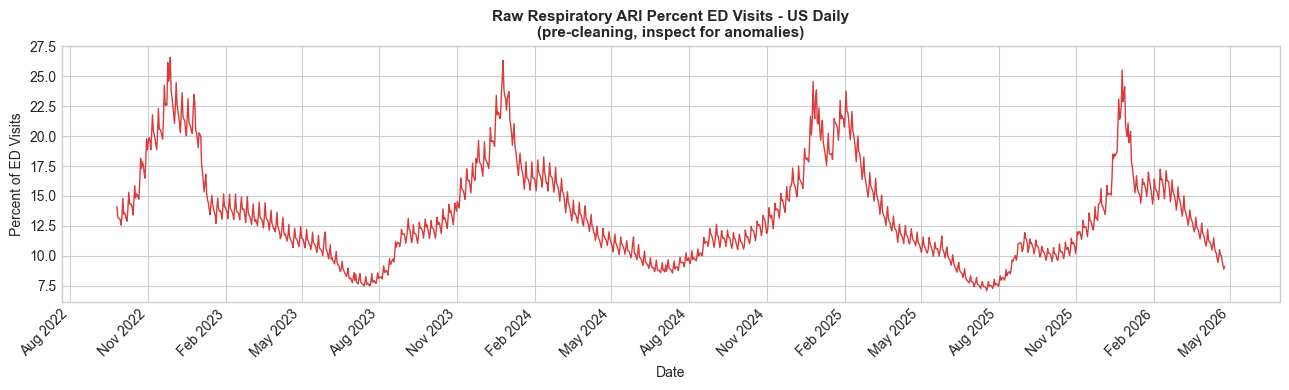

In [18]:
# Visualize the respiratory time series to check for any anomalies
resp_ari_us_sorted = resp_ari_us.copy()
resp_ari_us_sorted['date'] = pd.to_datetime(resp_ari_us_sorted['date'], format='mixed')
resp_ari_us_sorted = resp_ari_us_sorted.sort_values('date')

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(resp_ari_us_sorted['date'], resp_ari_us_sorted['percent_visits'],
        color='#d62728', linewidth=1, alpha=0.9)
ax.set_title('Raw Respiratory ARI Percent ED Visits - US Daily\n(pre-cleaning, inspect for anomalies)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Percent of ED Visits')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('outputs/figures/profile_respiratory_raw.png', dpi=150, bbox_inches='tight')
plt.show()